<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


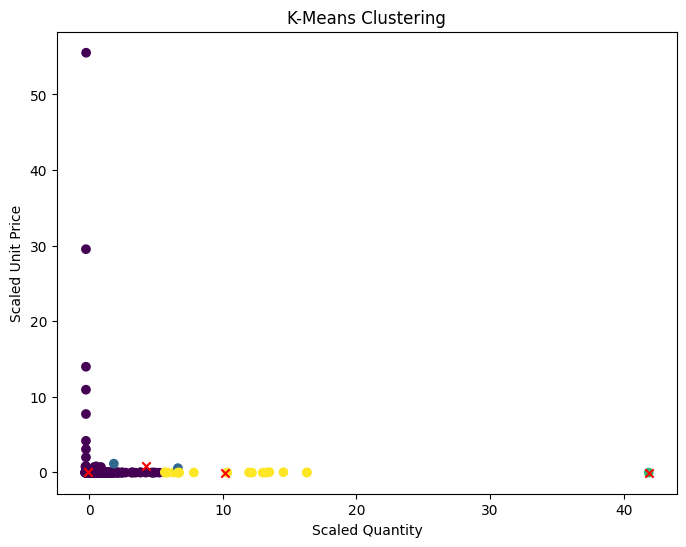

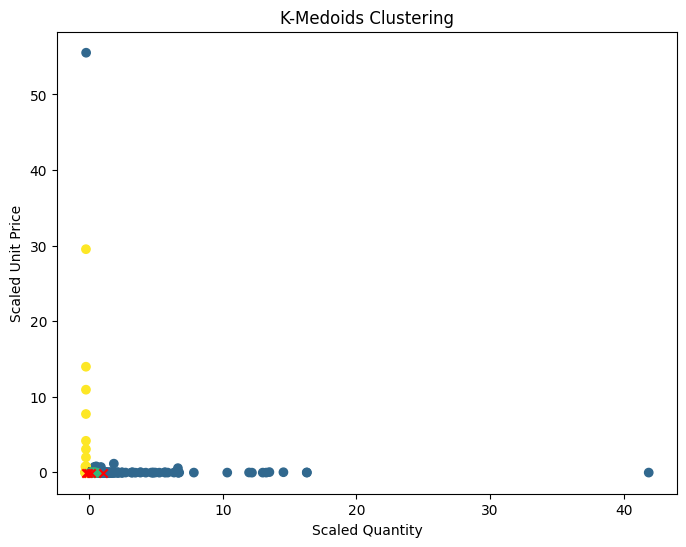

K-Means WCSS: 5957.355378699311
K-Medoids Dissimilarities: 755.6384975924841
Clustered customer data saved to 'Clustered_Customers.csv'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

# Load the dataset
file_path = "OnlineRetail.xlsx"  # Update with your actual file path
data = pd.read_excel(file_path)

# Inspect the data
data.info()

# Data Preprocessing
# Drop rows with missing values
data.dropna(subset=["CustomerID", "Quantity", "UnitPrice"], inplace=True)

# Create features for clustering
# Aggregate data to find total quantity and total spending per customer
customer_data = data.groupby("CustomerID").agg({
    "Quantity": "sum",
    "UnitPrice": "mean"
}).reset_index()

# Add total spending feature
customer_data["TotalSpending"] = customer_data["Quantity"] * customer_data["UnitPrice"]

# Select features for clustering
features = customer_data[["Quantity", "UnitPrice", "TotalSpending"]]

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 1. K-Means Clustering
k = 4  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels to the customer data
customer_data["KMeans_Cluster"] = kmeans_clusters

# Visualize K-Means Clusters
plt.figure(figsize=(8, 6))
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=kmeans_clusters, cmap="viridis")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c="red", marker="x")
plt.xlabel("Scaled Quantity")
plt.ylabel("Scaled Unit Price")
plt.title("K-Means Clustering")
plt.show()

# 2. K-Medoids Clustering
kmedoids = KMedoids(n_clusters=k, random_state=42)
kmedoids_clusters = kmedoids.fit_predict(scaled_features)

# Add cluster labels to the customer data
customer_data["KMedoids_Cluster"] = kmedoids_clusters

# Visualize K-Medoids Clusters
plt.figure(figsize=(8, 6))
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=kmedoids_clusters, cmap="viridis")
plt.scatter(kmedoids.cluster_centers_[:, 0], kmedoids.cluster_centers_[:, 1], c="red", marker="x")
plt.xlabel("Scaled Quantity")
plt.ylabel("Scaled Unit Price")
plt.title("K-Medoids Clustering")
plt.show()

# Evaluate within-cluster sum of squares (WCSS) for K-Means
kmeans_wcss = np.sum([np.sum((scaled_features[kmeans_clusters == i] - kmeans.cluster_centers_[i]) ** 2) for i in range(k)])
print("K-Means WCSS:", kmeans_wcss)

# Evaluate within-cluster sum of dissimilarities for K-Medoids
kmedoids_dissimilarities = kmedoids.inertia_
print("K-Medoids Dissimilarities:", kmedoids_dissimilarities)

# Save Results
customer_data.to_csv("Clustered_Customers.csv", index=False)
print("Clustered customer data saved to 'Clustered_Customers.csv'")


In [ ]:
from google.colab import files
uploaded = files.upload()  # Allows file upload


Saving OnlineRetail.xlsx to OnlineRetail.xlsx
